# Proyecto: Aplicación de Redes Neuronales Convolucionales para Detección de Poses en Imágenes

**Autores**: Julen Benages y Gorka Férnandez  
**Fecha**: Diciembre 2025  
**Descripción**: Implementamos modelos avanzado de estimación de poses usando el dataset MPII.


## Definición del Problema
Problema: Regresión de coordenadas de keypoints (x,y) de la cabeza y muñecas de una persona en una imagen para estimación de poses. Predecimos los 3 keypoints (Cabeza y Muñecas) de MPII normalizados [0,1].

## ArquitecturaS Seleccionada: PCT (Hybrid Transformer-CNN)
  ### Arquitectura 1
  - Fine-tunning del modelo convolucional RESNET-50
  

  ### Arquitectura 2
  - Reutilizamos la CNN fine-tuneada previamente (freezeando los pesos)
  - Añadimos un transformer que le da contexto al modelo
  - Finalmente compuesto por unas capas lineales
  




##Configuraciones y carga de imagenes

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import numpy as np
import os
from google.colab import drive
from PIL import Image
import matplotlib.pyplot as plt
import yaml

##Conectamos con drive
drive.mount('/content/drive', force_remount=True)

##Configuramos las rutas
path_proyecto = '/content/drive/MyDrive/MPII_proyectoDefinitivo'
path_dataset = os.path.join(path_proyecto, 'scripts/dataset')
path_imagenes = './training/imagenes/'
images_dir = os.path.join(path_dataset, 'images')
labels_dir = os.path.join(path_dataset, 'labels')


training_images = os.path.join(images_dir, 'train')
validation_images = os.path.join(images_dir, 'val')
test_images = os.path.join(images_dir, 'test')
training_labels = os.path.join(labels_dir, 'train')
validation_labels = os.path.join(labels_dir, 'val')
test_labels = os.path.join(labels_dir, 'test')


##Verificamos que hemos cargado las carpetas correctamente
print("Rutas configuradas:")
print(f"Train images: {training_images} (exists: {os.path.exists(training_images)})")
print(f"Val images: {validation_images} (exists: {os.path.exists(validation_images)})")
print(f"Test images: {test_images} (exists: {os.path.exists(test_images)})")
print(f"Train labels: {training_labels} (exists: {os.path.exists(training_labels)})")
print(f"Val labels: {validation_labels} (exists: {os.path.exists(validation_labels)})")
print(f"Test labels: {test_labels} (exists: {os.path.exists(test_labels)})")


Mounted at /content/drive
Rutas configuradas:
Train images: /content/drive/MyDrive/MPII_proyectoDefinitivo/scripts/dataset/images/train (exists: True)
Val images: /content/drive/MyDrive/MPII_proyectoDefinitivo/scripts/dataset/images/val (exists: True)
Test images: /content/drive/MyDrive/MPII_proyectoDefinitivo/scripts/dataset/images/test (exists: True)
Train labels: /content/drive/MyDrive/MPII_proyectoDefinitivo/scripts/dataset/labels/train (exists: True)
Val labels: /content/drive/MyDrive/MPII_proyectoDefinitivo/scripts/dataset/labels/val (exists: True)
Test labels: /content/drive/MyDrive/MPII_proyectoDefinitivo/scripts/dataset/labels/test (exists: True)


##GPU/CPU

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


##ARQUITECTURA 1: FINE-TUNNING DE RESNET-50

###Métrica del accuracy

Acierto si distancia <= threshold * head_size.

In [ ]:
def calcular_pckh_manual(preds, gts, head_sizes, masks, threshold=0.3):

    distances = np.linalg.norm(preds - gts, axis=-1)
    error_thresholds = threshold * head_sizes
    correct_keypoints = distances <= error_thresholds

    valid_correct = correct_keypoints & masks
    visible_points = np.sum(masks)

    if visible_points == 0:
        return 0.0

    return np.sum(valid_correct) / visible_points

##Dataloader
Ahora vamos a definir el dataloader para cargar correctamente las imagenes de nuestro dataset MPII

In [ ]:
class MPIIPoseDataset(Dataset):
    def __init__(self, image_dir, label_dir, target_size=(224, 224), transform=None):
        self.image_dir = image_dir
        self.label_dir = label_dir
        self.transform = transform
        self.target_size = target_size
        self.images = sorted([f for f in os.listdir(image_dir) if f.endswith(('.jpg', '.png'))])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.image_dir, img_name)

        ##Cargamos la imagen
        img = Image.open(img_path).convert("RGB")
        w_orig, h_orig = img.size

        ##Definimos las rutas
        txt_name = img_name.replace('.jpg', '.txt').replace('.png', '.txt')
        label_path = os.path.join(self.label_dir, txt_name)


        ##Inicializamos los keypoints y los parametros para el accuracy
        keypoints = np.zeros((3, 2), dtype=np.float32)
        visible_mask = np.zeros(3, dtype=bool)
        head_size_original = h_orig * 0.5


        try:
            if os.path.exists(label_path):
                labels = np.loadtxt(label_path, dtype=np.float32)
                if labels.ndim == 1: labels = labels.reshape(1, -1)

                raw_kps = labels[:, 1:3] ##Cojemos de la 1 a la 3 ya que son las columnas que contienen información sobre los keypoints
                limit = min(len(raw_kps), 3)

                is_normalized = np.max(raw_kps) <= 1.0

                if is_normalized:

                    keypoints[:limit, 0] = raw_kps[:limit, 0] * self.target_size[0]
                    keypoints[:limit, 1] = raw_kps[:limit, 1] * self.target_size[1]
                else:

                    scale_x = self.target_size[0] / w_orig
                    scale_y = self.target_size[1] / h_orig
                    keypoints[:limit, 0] = raw_kps[:limit, 0] * scale_x
                    keypoints[:limit, 1] = raw_kps[:limit, 1] * scale_y

                visible_mask[:limit] = True
        except:
            pass

        ##Reescalamos la imagen
        img = img.resize(self.target_size)

        ##Ajustamos el  head_size a la nueva escala de 224
        scale_y_global = self.target_size[1] / h_orig
        head_size_final = head_size_original * scale_y_global

        if self.transform:
            img = self.transform(img)

        return img, torch.from_numpy(keypoints), torch.from_numpy(visible_mask), head_size_final

#ARQUITECTURA 1: ResNet-50
-Cargamos el modelo preentrenado y congelamos algunas capas iniciales, ya que no disponemos de muchas fotos y no podemos permitirnos fine-tunear el modelo entero.

In [ ]:
class PoseResNet(nn.Module):
    def __init__(self, num_keypoints=3):
        super(PoseResNet, self).__init__()
        ##Cargamos ResNet-50 con los pesos pre-entrenados
        self.backbone = models.resnet50(weights='DEFAULT')

        ##Congelamos las capas iniciales
        modules_to_freeze = [
            self.backbone.conv1,
            self.backbone.bn1,
            self.backbone.layer1,
            self.backbone.layer2
        ]

        ##Las ponemos como que no necesitan gradiente para que pytorch no toque estos pesos
        for module in modules_to_freeze:
            for param in module.parameters():
                param.requires_grad = False

        ##Añadimos una capa lineal y dropout para que evitar overfiting que hemos tenido en entrenamientos anteriores
        num_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_keypoints * 2)
        )

    def forward(self, x):
        return self.backbone(x)

##Transforms de nuestros datos

In [ ]:
train_transform = transforms.Compose([
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3)], p=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

##Configuración de hiperparámetros

-Lo primero que vamos a hacer es importar la librería optuna que vimos en la asignatura de Heurísticos de búsqueda y ver cual es la mejor configuración posible.

-Al igual que el training lo hemos ejecutado en nuestro pc Local

In [ ]:
!pip install optuna

In [ ]:

import optuna

##Definimos la función de objetivo para Optuna
def objective(trial):
    ##Hiperparámetros a optimizar
    lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)  # Log para explorar órdenes
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)

    train_dataset = MPIIPoseDataset(training_images, training_labels, transform=train_transform)
    val_dataset = MPIIPoseDataset(validation_images, validation_labels, transform=val_transform)

    ##Dataloaders con nuevo batch
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset , batch_size=batch_size, shuffle=False)

    ##Modelo desde cero con nuevos params
    model = PoseResNet().to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    criterion = nn.MSELoss()
    epochs = 8
    best_val_loss = float('inf')
    for epoch in range(epochs):
        ##Train
        model.train()
        train_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        ##Val
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                val_loss += criterion(outputs, labels).item()

        val_loss /= len(val_loader)
        scheduler.step()

        if val_loss < best_val_loss:
            best_val_loss = val_loss

    return best_val_loss

##Ejecutamos Optuna
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=20)

##Mejores hiperparámetros
print("Mejores hiperparámetros:")
print(study.best_params)
print(f"Mejor val_loss: {study.best_value:.6f}")

[I 2026-01-16 10:50:04,738] A new study created in memory with name: no-name-81e6bc74-74d3-40e1-b757-983db972e33c
[W 2026-01-16 10:50:49,720] Trial 0 failed with parameters: {'lr': 0.0038126487200775224, 'batch_size': 64, 'weight_decay': 0.00018363760375116642} because of the following error: ValueError('too many values to unpack (expected 2)').
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 205, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipython-input-2814483216.py", line 29, in objective
    for images, labels in train_loader:
        ^^^^^^^^^^^^^^
ValueError: too many values to unpack (expected 2)
[W 2026-01-16 10:50:49,722] Trial 0 failed with value None.


ValueError: too many values to unpack (expected 2)

##Training de nuestra CNN

-Aqui hemos definido el entrenamiento de nuestro modelo pero lo hemos ejecutado en nuestro PC, ya que colab no nos daba GPUS e iba muy lento.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import csv
import os

##Aquí hemos puesto directamente los mejores parámetros que nos ha dado optuna
CONFIG = {
    'lr': 0.00017,
    'batch_size': 16,
    'weight_decay': 1e-5,
    'epochs': 100,
    'patience': 12
}

def ejecutar_entrenamiento_directo():
    print(f"Iniciando entrenamiento en: {device}")



    full_train_ds = MPIIPoseDataset(training_images, training_labels, transform=train_transform)
    full_val_ds = MPIIPoseDataset(validation_images, validation_labels, transform=val_transform)

    train_loader = DataLoader(full_train_ds, batch_size=CONFIG['batch_size'], shuffle=True, num_workers=2)
    val_loader = DataLoader(full_val_ds, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=2)


    model = PoseResNet(num_keypoints=3).to(device)

    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=CONFIG['lr'],
        weight_decay=CONFIG['weight_decay']
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    criterion = nn.MSELoss()


    best_val_acc = 0.0
    early_stopping_counter = 0
    path_to_save_model = os.path.join(path_proyecto, 'best_resnet_pose_pck2.pth')

    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    print(f"Modelo guardado en: {path_to_save_model}")

    for epoch in range(CONFIG['epochs']):

        ##train
        model.train()
        running_loss = 0.0

        for images, kps, mask, _ in train_loader:
            images = images.to(device)
            kps_flat = kps.view(images.size(0), -1).to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, kps_flat)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)

        ##val
        model.eval()
        val_running_loss = 0.0
        all_preds, all_gts, all_masks, all_head_sizes = [], [], [], []

        with torch.no_grad():
            for images, kps, mask, head_sizes in val_loader:
                images = images.to(device)
                kps_flat = kps.view(images.size(0), -1).to(device)

                outputs = model(images)
                loss = criterion(outputs, kps_flat)
                val_running_loss += loss.item() * images.size(0)

                ##Guardamos los datos para las métricas
                all_preds.append(outputs.cpu().numpy().reshape(-1, 3, 2))
                all_gts.append(kps.numpy())
                all_masks.append(mask.numpy())
                all_head_sizes.append(head_sizes.numpy().reshape(-1, 1))

        epoch_val_loss = val_running_loss / len(val_loader.dataset)


        all_preds = np.concatenate(all_preds, axis=0)
        all_gts = np.concatenate(all_gts, axis=0)
        all_masks = np.concatenate(all_masks, axis=0)
        all_head_sizes = np.concatenate(all_head_sizes, axis=0)

        acc_decimal = calcular_pckh_manual(all_preds, all_gts, all_head_sizes, all_masks, threshold=0.3)
        current_acc = acc_decimal * 100.0


        history['train_loss'].append(epoch_loss)
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(current_acc)

        scheduler.step(epoch_val_loss)

        print(f"Epoch {epoch+1}/{CONFIG['epochs']} | T.Loss: {epoch_loss:.4f} | V.Loss: {epoch_val_loss:.4f} | PCKh: {current_acc:.2f}%")

        ##Early stopoping
        if current_acc > best_val_acc:
            best_val_acc = current_acc
            early_stopping_counter = 0
            torch.save(model.state_dict(), path_to_save_model)
            print(f"Modelo guardado.")
        else:
            early_stopping_counter += 1
            print(f"No mejora, valor actual del patience: {early_stopping_counter}/{CONFIG['patience']}")

        if early_stopping_counter >= CONFIG['patience']:
            print("\n Early Stopping activado.")
            break



    csv_path = os.path.join(path_proyecto, 'registro_entrenamiento.csv')
    with open(csv_path, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(['Epoch', 'Train Loss', 'Val Loss', 'Val PCK Acc (%)'])
        for i in range(len(history['train_loss'])):
            writer.writerow([i + 1, history['train_loss'][i], history['val_loss'][i], history['val_acc'][i]])

    ##Gráficos
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    ax1.plot(history['train_loss'], label='Train Loss')
    ax1.plot(history['val_loss'], label='Val Loss')
    ax1.set_title('Loss (MSE)')
    ax1.set_xlabel('Epochs')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(history['val_acc'], label='Val PCKh Accuracy', color='green')
    ax2.set_title(f'PCKh Accuracy (Mejor: {best_val_acc:.2f}%)')
    ax2.set_xlabel('Epochs')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    save_plot_path = os.path.join(path_proyecto, 'graficas_entrenamiento_pck.png')
    plt.savefig(save_plot_path)
    plt.show()
    print("Entrenamiento finalizado.")


if os.path.exists(training_images):
    ejecutar_entrenamiento_directo()
else:
    print("Error, no se encuentran las imágenes de entrenamiento")

##GRAFICAS DEL ENTRENAMIENTO

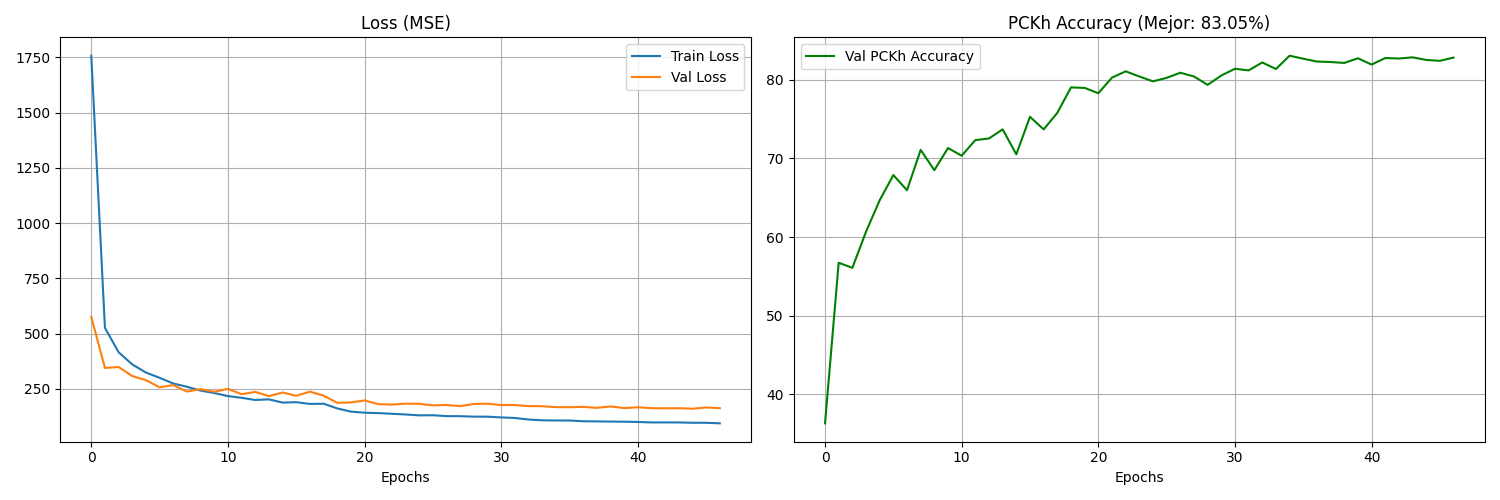

##Test

In [ ]:
import torch
import numpy as np
from torch.utils.data import DataLoader

##ruta de los pesos
path_weights = '/content/drive/MyDrive/MPII_proyectoDefinitivo/scripts/colab/best_resnet_pose_pck2.pth'

def evaluar_test(model_path, test_loader, device):
    print("Cargando modelo para test")

    # Inicializar modelo y cargar pesos
    model = PoseResNet(num_keypoints=3).to(device)

    if os.path.exists(model_path):
        # map_location es importante por si entrenaste en GPU y evalúas en CPU o viceversa
        model.load_state_dict(torch.load(model_path, map_location=device))
        print("Pesos cargados correctamente.")
    else:
        print(f"Error, no se encuentra el modelo-preentrenado: {model_path}")
        return

    model.eval()

    all_preds = []
    all_gts = []
    all_masks = []
    all_head_sizes = []


    with torch.no_grad():
        for images, kps, mask, head_sizes in test_loader:
            images = images.to(device)

            # Forward pass
            outputs = model(images)

            # Guardar resultados
            all_preds.append(outputs.cpu().numpy().reshape(-1, 3, 2))
            all_gts.append(kps.numpy())
            all_masks.append(mask.numpy())
            all_head_sizes.append(head_sizes.numpy().reshape(-1, 1))

    # Concatenar todo
    all_preds = np.concatenate(all_preds, axis=0)
    all_gts = np.concatenate(all_gts, axis=0)
    all_masks = np.concatenate(all_masks, axis=0)
    all_head_sizes = np.concatenate(all_head_sizes, axis=0)

    # Calcular PCKh
    # threshold 0.5 es estándar en MPII, pero en tu script usabas 0.3.
    # Puedes ajustar según lo que busques reportar.
    acc_decimal = calcular_pckh_manual(all_preds, all_gts, all_head_sizes, all_masks, threshold=0.3)

    print("-" * 30)
    print(f"Accuracy final en test (PCKh@0.3(treshold que hemos utilizado)): {acc_decimal * 100:.2f}%")
    print("-" * 30)
    return model, all_preds, all_gts

# Crear Dataset y Loader de Test
# Usamos val_transform porque en test no queremos ruido (data augmentation), solo normalizar
test_dataset = MPIIPoseDataset(test_images, test_labels, transform=val_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Ejecutar evaluación
if os.path.exists(path_weights):
    model_cargado, preds, gts = evaluar_test(path_weights, test_loader, device)
else:
    print(f"Cuidado: No se encuentra el archivo .pth en {path_weights}. Verifica la ruta en Drive.")

Cargando modelo para test
Pesos cargados correctamente.
------------------------------
Accuracy final en test (PCKh@0.3(treshold que hemos utilizado)): 93.55%
------------------------------


##Visualización

Visualizando resultados del modelo
Pesos cargados correctamente.


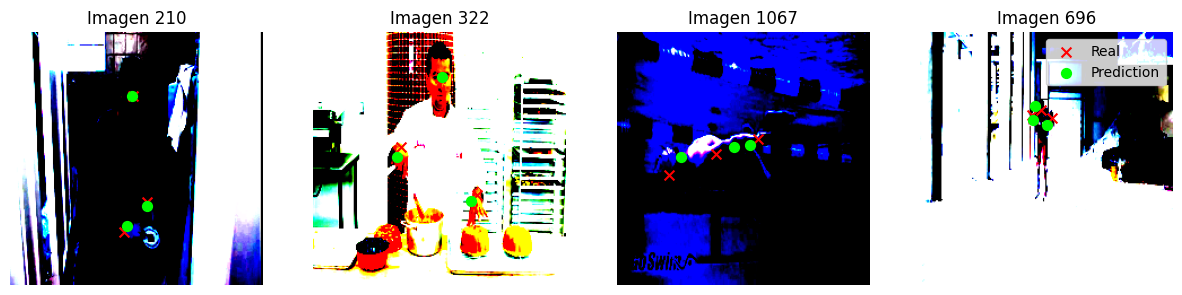

In [ ]:
import matplotlib.pyplot as plt
import random

def visualizar_predicciones(dataset, model, device, num_samples=3):
    model.eval()

    ##Generamos unos indices aleatorios a visualizar
    indices = random.sample(range(len(dataset)), num_samples)

    fig, axes = plt.subplots(1, num_samples, figsize=(15, 5))
    if num_samples == 1: axes = [axes]

    for i, idx in enumerate(indices):
        img_tensor, kps_gt, mask, _ = dataset[idx]


        inv_mean = torch.tensor([-0.485/0.229, -0.456/0.224, -0.406/0.225]).view(3, 1, 1)
        inv_std = torch.tensor([1/0.229, 1/0.224, 1/0.225]).view(3, 1, 1)

        img_show = img_tensor.clone().detach()
        img_show = img_show * inv_std + inv_mean
        img_show = torch.clamp(img_show, 0, 1)
        img_show = img_show.permute(1, 2, 0).numpy()


        input_tensor = img_tensor.unsqueeze(0).to(device)
        with torch.no_grad():
            output = model(input_tensor)
            pred_kps = output.cpu().numpy().reshape(3, 2)


        axes[i].imshow(img_show)

        ##Real rojo
        visible_gt = kps_gt[mask]
        if len(visible_gt) > 0:
            axes[i].scatter(visible_gt[:, 0], visible_gt[:, 1], c='red', marker='x', s=50, label='Real')

        ##Predicción del modelo verde
        axes[i].scatter(pred_kps[:, 0], pred_kps[:, 1], c='lime', marker='o', s=50, label='Prediction')

        axes[i].set_title(f"Imagen {idx}")
        axes[i].axis('off')

    plt.legend()
    plt.show()


print("Visualizando resultados del modelo")
path_weights = '/content/drive/MyDrive/MPII_proyectoDefinitivo/scripts/colab/best_resnet_pose_pck2.pth'
model = PoseResNet(num_keypoints=3).to(device)
if os.path.exists(path_weights):

    model.load_state_dict(torch.load(path_weights, map_location=device))
    print("Pesos cargados correctamente.")
else:
    print(f"Error, no se encuentra el modelo-preentrenado: {path_weights}")


test_dataset = MPIIPoseDataset(test_images, test_labels, transform=val_transform)
visualizar_predicciones(test_dataset, model, device, num_samples=4)

##ARQUITECTURA 2: CNN + TRANSFORMER

##Métrica de accuracy

In [3]:
def calcular_pckh_manual(preds, gts, head_sizes, masks, threshold=0.3):
    """
    Calcula el porcentaje de keypoints correctos (PCK) normalizado por el tamaño de la cabeza (h).
    """
    distances = np.linalg.norm(preds - gts, axis=-1)
    error_thresholds = threshold * head_sizes
    correct_keypoints = distances <= error_thresholds
    valid_correct = correct_keypoints & masks
    visible_points = np.sum(masks)

    if visible_points == 0: return 0.0
    return np.sum(valid_correct) / visible_points

##Redefinimos el dataloader

In [7]:

class MPIIPoseDataset(Dataset):
    def __init__(self, image_dir, label_dir, scale_dir, target_size=(224, 224), heatmap_size=(112, 112), sigma=3, transform=None):
        self.image_dir = image_dir
        self.label_dir = label_dir
        self.scale_dir = scale_dir
        self.transform = transform
        self.target_size = target_size
        self.heatmap_size = heatmap_size
        self.sigma = sigma
        self.images = sorted([f for f in os.listdir(image_dir) if f.endswith(('.jpg', '.png'))])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.image_dir, img_name)
        img = Image.open(img_path).convert("RGB")
        w_orig, h_orig = img.size

        txt_name = img_name.replace('.jpg', '.txt').replace('.png', '.txt')
        label_path = os.path.join(self.label_dir, txt_name)
        scale_path = os.path.join(self.scale_dir, txt_name)


        keypoints = np.zeros((3, 2), dtype=np.float32)
        visible_mask = np.zeros(3, dtype=bool)
        head_size_original = h_orig * 0.5

        try:
            if os.path.exists(label_path):
                labels = np.loadtxt(label_path, dtype=np.float32)
                if labels.ndim == 1: labels = labels.reshape(1, -1)
                raw_kps = labels[:, 1:3]
                limit = min(len(raw_kps), 3)
                is_normalized = np.max(raw_kps) <= 1.0

                if is_normalized:
                    keypoints[:limit, 0] = raw_kps[:limit, 0] * self.target_size[0]
                    keypoints[:limit, 1] = raw_kps[:limit, 1] * self.target_size[1]
                else:
                    scale_x = self.target_size[0] / w_orig
                    scale_y = self.target_size[1] / h_orig
                    keypoints[:limit, 0] = raw_kps[:limit, 0] * scale_x
                    keypoints[:limit, 1] = raw_kps[:limit, 1] * scale_y
                visible_mask[:limit] = True
        except: pass

        try:
            if os.path.exists(scale_path):
                with open(scale_path, 'r') as f:
                    content = f.read().strip()
                scale_val = float(content)
                head_size_original = scale_val * 200.0
        except: pass

        img = img.resize(self.target_size)
        scale_y_global = self.target_size[1] / h_orig
        head_size_final = head_size_original * scale_y_global

        heatmaps_gt = self.generate_heatmaps(keypoints, visible_mask)

        if self.transform:
            img = self.transform(img)

        return img, torch.from_numpy(heatmaps_gt), torch.from_numpy(keypoints), torch.from_numpy(visible_mask), head_size_final

    def generate_heatmaps(self, keypoints, visible_mask):
        heatmaps = np.zeros((3, *self.heatmap_size), dtype=np.float32)
        for i in range(3):
            if visible_mask[i]:
                x, y = keypoints[i]
                x = int(x * (self.heatmap_size[1] / self.target_size[0]))
                y = int(y * (self.heatmap_size[0] / self.target_size[1]))
                heatmaps[i] = self.gaussian_heatmap(x, y)
        return heatmaps

    def gaussian_heatmap(self, cx, cy):
        h, w = self.heatmap_size
        x, y = np.meshgrid(np.arange(w), np.arange(h))
        if cx < 0 or cx >= w or cy < 0 or cy >= h: return np.zeros((h, w), dtype=np.float32)
        heatmap = np.exp(-((x - cx)**2 + (y - cy)**2) / (2 * self.sigma**2))
        return heatmap

##Transformaciones
transform = transforms.Compose([
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

##Definimos la nueva arquitectura: CNN (ResNet-50 fine-tuneado) + Transformer (TokenPose)

In [8]:

class TokenPosePro(nn.Module):
    def __init__(self, num_keypoints=3, feature_dim=256, nhead=8, num_layers=4):
        super(TokenPosePro, self).__init__()

        resnet = models.resnet50(weights=None)
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])

        self.to_patch_embedding = nn.Conv2d(2048, feature_dim, kernel_size=1)
        self.keypoint_tokens = nn.Parameter(torch.zeros(1, num_keypoints, feature_dim))
        self.pos_embedding_patches = self.build_2d_sine_encoding(feature_dim, 7, 7)
        self.pos_embedding_tokens = nn.Parameter(torch.randn(1, num_keypoints, feature_dim))

        encoder_layer = nn.TransformerEncoderLayer(d_model=feature_dim, nhead=nhead, dim_feedforward=1024, batch_first=True, activation='gelu')
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Decoder 112x112
        self.deconv_layers = nn.Sequential(
            nn.ConvTranspose2d(feature_dim, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(),
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64, num_keypoints, kernel_size=4, stride=2, padding=1)
        )
        self._init_weights()

    def build_2d_sine_encoding(self, dim, height, width):
        y_embed = torch.arange(height, dtype=torch.float32).view(-1, 1).repeat(1, width).unsqueeze(0)
        x_embed = torch.arange(width, dtype=torch.float32).view(1, -1).repeat(height, 1).unsqueeze(0)
        y_embed = y_embed / height
        x_embed = x_embed / width
        dim_t = torch.arange(dim // 2, dtype=torch.float32)
        dim_t = 10000 ** (2 * (dim_t // 2) / (dim // 2))
        pos_x = x_embed[..., None] / dim_t
        pos_y = y_embed[..., None] / dim_t
        pos_x = torch.stack((pos_x[..., 0::2].sin(), pos_x[..., 1::2].cos()), dim=-1).flatten(-2)
        pos_y = torch.stack((pos_y[..., 0::2].sin(), pos_y[..., 1::2].cos()), dim=-1).flatten(-2)
        pos = torch.cat((pos_y, pos_x), dim=-1).view(-1, dim).unsqueeze(0)
        return nn.Parameter(pos, requires_grad=False)

    def _init_weights(self):
        nn.init.xavier_uniform_(self.keypoint_tokens)
        nn.init.trunc_normal_(self.pos_embedding_tokens, std=0.02)

    def forward(self, x):
        features = self.backbone(x)
        x_patches = self.to_patch_embedding(features).flatten(2).transpose(1, 2)
        B = x.shape[0]
        cls_tokens = self.keypoint_tokens.expand(B, -1, -1)
        x_in = torch.cat((cls_tokens, x_patches), dim=1)
        x_in[:, :3] += self.pos_embedding_tokens
        x_in[:, 3:] += self.pos_embedding_patches
        x_out = self.transformer(x_in)

        visual_tokens = x_out[:, 3:, :]
        feature_map = visual_tokens.transpose(1, 2).view(B, 256, 7, 7)
        heatmaps = self.deconv_layers(feature_map)
        heatmaps = torch.sigmoid(heatmaps)

        coords = self.heatmap_to_coord_refined(heatmaps)
        return heatmaps, coords

    def heatmap_to_coord_refined(self, heatmaps):
        B, K, H, W = heatmaps.shape
        heatmaps_flat = heatmaps.view(B, K, -1)
        idx = heatmaps_flat.argmax(dim=2)
        y = (idx // W).float()
        x = (idx % W).float()
        coords = torch.stack([x, y], dim=2)
        coords *= 2.0
        return coords

def load_backbone_weights(model, path):
    print(f"\n Cargando Backbone desde: {path}")
    if not os.path.exists(path):
        print("Error, no se encuentra el modelo CNN.")
        return
    state_dict = torch.load(path)
    new_dict = {}
    for k, v in state_dict.items():
        if 'backbone' in k:
            new_key = k.replace('backbone.', '')
            new_dict[new_key] = v
    try:
        model.backbone.load_state_dict(new_dict, strict=False)
        print("Pesos cargados correctamente.")
    except: pass

##TRAINING

In [ ]:
def training_pro():
    print(f"\n Entrenando TokenPose PRO (112x112)")

    ##Verificamos que las rutas existen
    if not os.path.exists(training_images):
        print(f"Error, no se encuentra la carpeta de imágenes: {training_images}")
        return
    scales_dir = '/content/drive/MyDrive/MPII_proyectoDefinitivo/scripts/dataset/labels2'
    train_ds = MPIIPoseDataset(training_images, training_labels, scales_dir, transform=transform)
    val_ds = MPIIPoseDataset(validation_images, validation_labels, scales_dir, transform=transform)

    train_loader = DataLoader(train_ds, batch_size=12, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=12, shuffle=False, num_workers=2, pin_memory=True)
    path_transformer = "'/content/drive/MyDrive/MPII_proyectoDefinitivo/scripts/transformer.pth"

    model = TokenPosePro(num_keypoints=3).to(device)

    ##Cargamos los pesos del pre-entrenados del CNN
    path_weights = '/content/drive/MyDrive/MPII_proyectoDefinitivo/scripts/colab/best_resnet_pose_pck2.pth'
    if os.path.exists(path_weights):
        load_backbone_weights(model, path_weights)
    else:
        print("Error, no se ha encontraddo el modelo ResNet preentrenado.")

    optimizer = optim.AdamW([
        {'params': model.backbone.parameters(), 'lr': 1e-5},
        {'params': model.transformer.parameters(), 'lr': 1e-4},
        {'params': model.deconv_layers.parameters(), 'lr': 1e-4}
    ], weight_decay=1e-4)

    criterion = nn.MSELoss()

    epochs = 100
    patience = 20
    early_stop_cnt = 0
    best_acc = 0.0
    history = {'val_acc': [], 'train_loss': []}

    print(f"Este modelo Transformer se guardará en: {path_transformer}")

    for epoch in range(epochs):
        ##Train
        model.train()
        run_loss = 0.0

        for imgs, heatmaps_gt, _, masks, _ in train_loader:
            imgs = imgs.to(device)
            heatmaps_gt = heatmaps_gt.to(device)
            masks = masks.to(device)

            optimizer.zero_grad()
            heatmaps_pred, _ = model(imgs)

            mask_tensor = masks.float().view(-1, 3, 1, 1)


            loss = criterion(heatmaps_pred * mask_tensor, heatmaps_gt * mask_tensor) * 1000.0

            loss.backward()
            optimizer.step()
            run_loss += loss.item()

        epoch_loss = run_loss / len(train_loader)

        ##Val
        model.eval()
        all_preds = []
        all_gts = []
        all_masks = []
        all_head_sizes = []

        with torch.no_grad():
            for imgs, _, kps_real, masks, head_sizes in val_loader:
                imgs = imgs.to(device)
                _, coords_pred = model(imgs)
                all_preds.append(coords_pred.cpu().numpy())
                all_gts.append(kps_real.numpy())
                all_masks.append(masks.numpy())
                all_head_sizes.append(head_sizes.numpy().reshape(-1, 1))

        current_acc = calcular_pckh_manual(
            preds=np.concatenate(all_preds),
            gts=np.concatenate(all_gts),
            head_sizes=np.concatenate(all_head_sizes),
            masks=np.concatenate(all_masks),
            threshold=0.3
        ) * 100

        print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss:.6f} | Val PCKh@0.3: {current_acc:.2f}%")

        history['val_acc'].append(current_acc)
        history['train_loss'].append(epoch_loss)

        if current_acc > best_acc:
            best_acc = current_acc
            early_stop_cnt = 0
            torch.save(model.state_dict(), path_transformer)
            print(f"  --> ¡Récord! {current_acc:.2f}%")
        else:
            early_stop_cnt += 1
            if early_stop_cnt >= patience:
                print("Early stopping activado.")
                break

    ##Gráficos
    plt.figure()
    plt.plot(history['val_acc'])
    plt.title('TokenPose PRO Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.grid(True)
    plt.savefig(os.path.join(path_imagenes, 'tokenpose_pro_fix.png'))
    plt.show()
    print("¡Fin!")

##Ejecutamos el training
if __name__ == '__main__':
    training_pro()

##GRAFICA EVOLUCIÓN ACCURACY

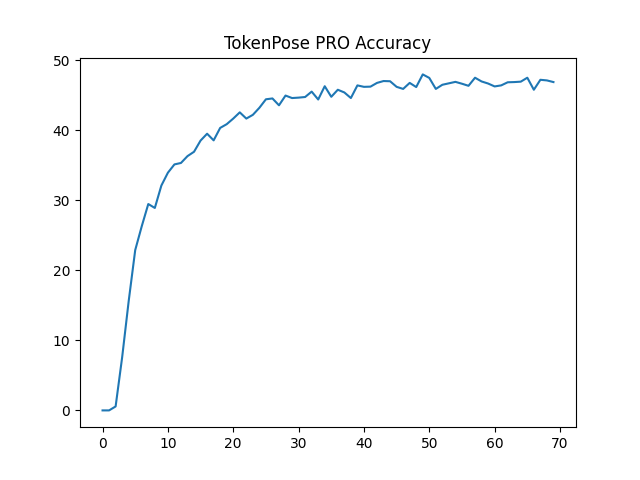

##TEST

In [13]:
import torch
from torch.utils.data import DataLoader
from torchvision import transforms
import os
import numpy as np

# --- 1. DEFINIR TRANSFORMACIONES (Esto arregla tu error NameError) ---
val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Ruta de los pesos (Asegúrate que es el archivo del Transformer)
path_weights = '/content/drive/MyDrive/MPII_proyectoDefinitivo/scripts/colab/best_tokenpose_pro.pth'

# Ruta de las escalas (labels2)
scales_dir = '/content/drive/MyDrive/MPII_proyectoDefinitivo/scripts/dataset/labels2'

def evaluar_test(model_path, test_loader, device):
    print(f"Iniciando Test. Cargando pesos desde: {model_path}")

    # --- CORRECCIÓN 1: Usar TokenPosePro, no PoseResNet ---
    # Como tus pesos se llaman 'best_tokenpose_pro.pth', asumo que es el Transformer
    model = TokenPosePro(num_keypoints=3).to(device)

    if os.path.exists(model_path):
        # map_location evita errores si entrenaste en GPU y evalúas en CPU
        model.load_state_dict(torch.load(model_path, map_location=device))
        print("Pesos cargados correctamente")
    else:
        print(f"Error, no se encuentra el archivo: {model_path}")
        return

    model.eval()

    all_preds = []
    all_gts = []
    all_masks = []
    all_head_sizes = []

    print("Procesando imágenes")
    with torch.no_grad():
        # --- CORRECCIÓN 2: El Dataset devuelve 5 valores, ignoramos heatmaps_gt con '_' ---
        for images, _, kps, mask, head_sizes in test_loader:
            images = images.to(device)

            # Forward pass
            # --- CORRECCIÓN 3: TokenPosePro devuelve (heatmaps, coords) ---
            _, coords_pred = model(images)

            # Guardar resultados
            all_preds.append(coords_pred.cpu().numpy()) # Ya viene en formato [B, 3, 2]
            all_gts.append(kps.numpy())
            all_masks.append(mask.numpy())
            all_head_sizes.append(head_sizes.numpy().reshape(-1, 1))

    # Concatenar todo
    all_preds = np.concatenate(all_preds, axis=0)
    all_gts = np.concatenate(all_gts, axis=0)
    all_masks = np.concatenate(all_masks, axis=0)
    all_head_sizes = np.concatenate(all_head_sizes, axis=0)

    # Calcular PCKh
    acc_decimal = calcular_pckh_manual(all_preds, all_gts, all_head_sizes, all_masks, threshold=0.3)

    print("-" * 50)
    print(f"Accuracy Final en TEST (PCKh@0.3 treshold que hemos utilizado): {acc_decimal * 100:.2f}%")
    print("-" * 50)
    return model, all_preds, all_gts

# --- EJECUCIÓN ---

# Verificar que existen las rutas de test
if os.path.exists(test_images) and os.path.exists(scales_dir):
    # Crear Dataset y Loader
    test_dataset = MPIIPoseDataset(test_images, test_labels, scales_dir, transform=val_transform)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    # Ejecutar evaluación
    if os.path.exists(path_weights):
        model_cargado, preds, gts = evaluar_test(path_weights, test_loader, device)
    else:
        print(f"No se encuentra el archivo .pth en {path_weights}")
else:
    print("Error, rutas de dataset de test o scales incorrectas.")

Iniciando Test. Cargando pesos desde: /content/drive/MyDrive/MPII_proyectoDefinitivo/scripts/colab/best_tokenpose_pro.pth
Pesos cargados correctamente
Procesando imágenes
--------------------------------------------------
Accuracy Final en TEST (PCKh@0.3 treshold que hemos utilizado): 66.70%
--------------------------------------------------
